[SYSTEM] Rendering Graph A4: Violin Density Distribution (Patched)...
[SUCCESS] High-resolution density graph saved to: Graph_A4_Final_Faithfulness_Violin_FIXED.png


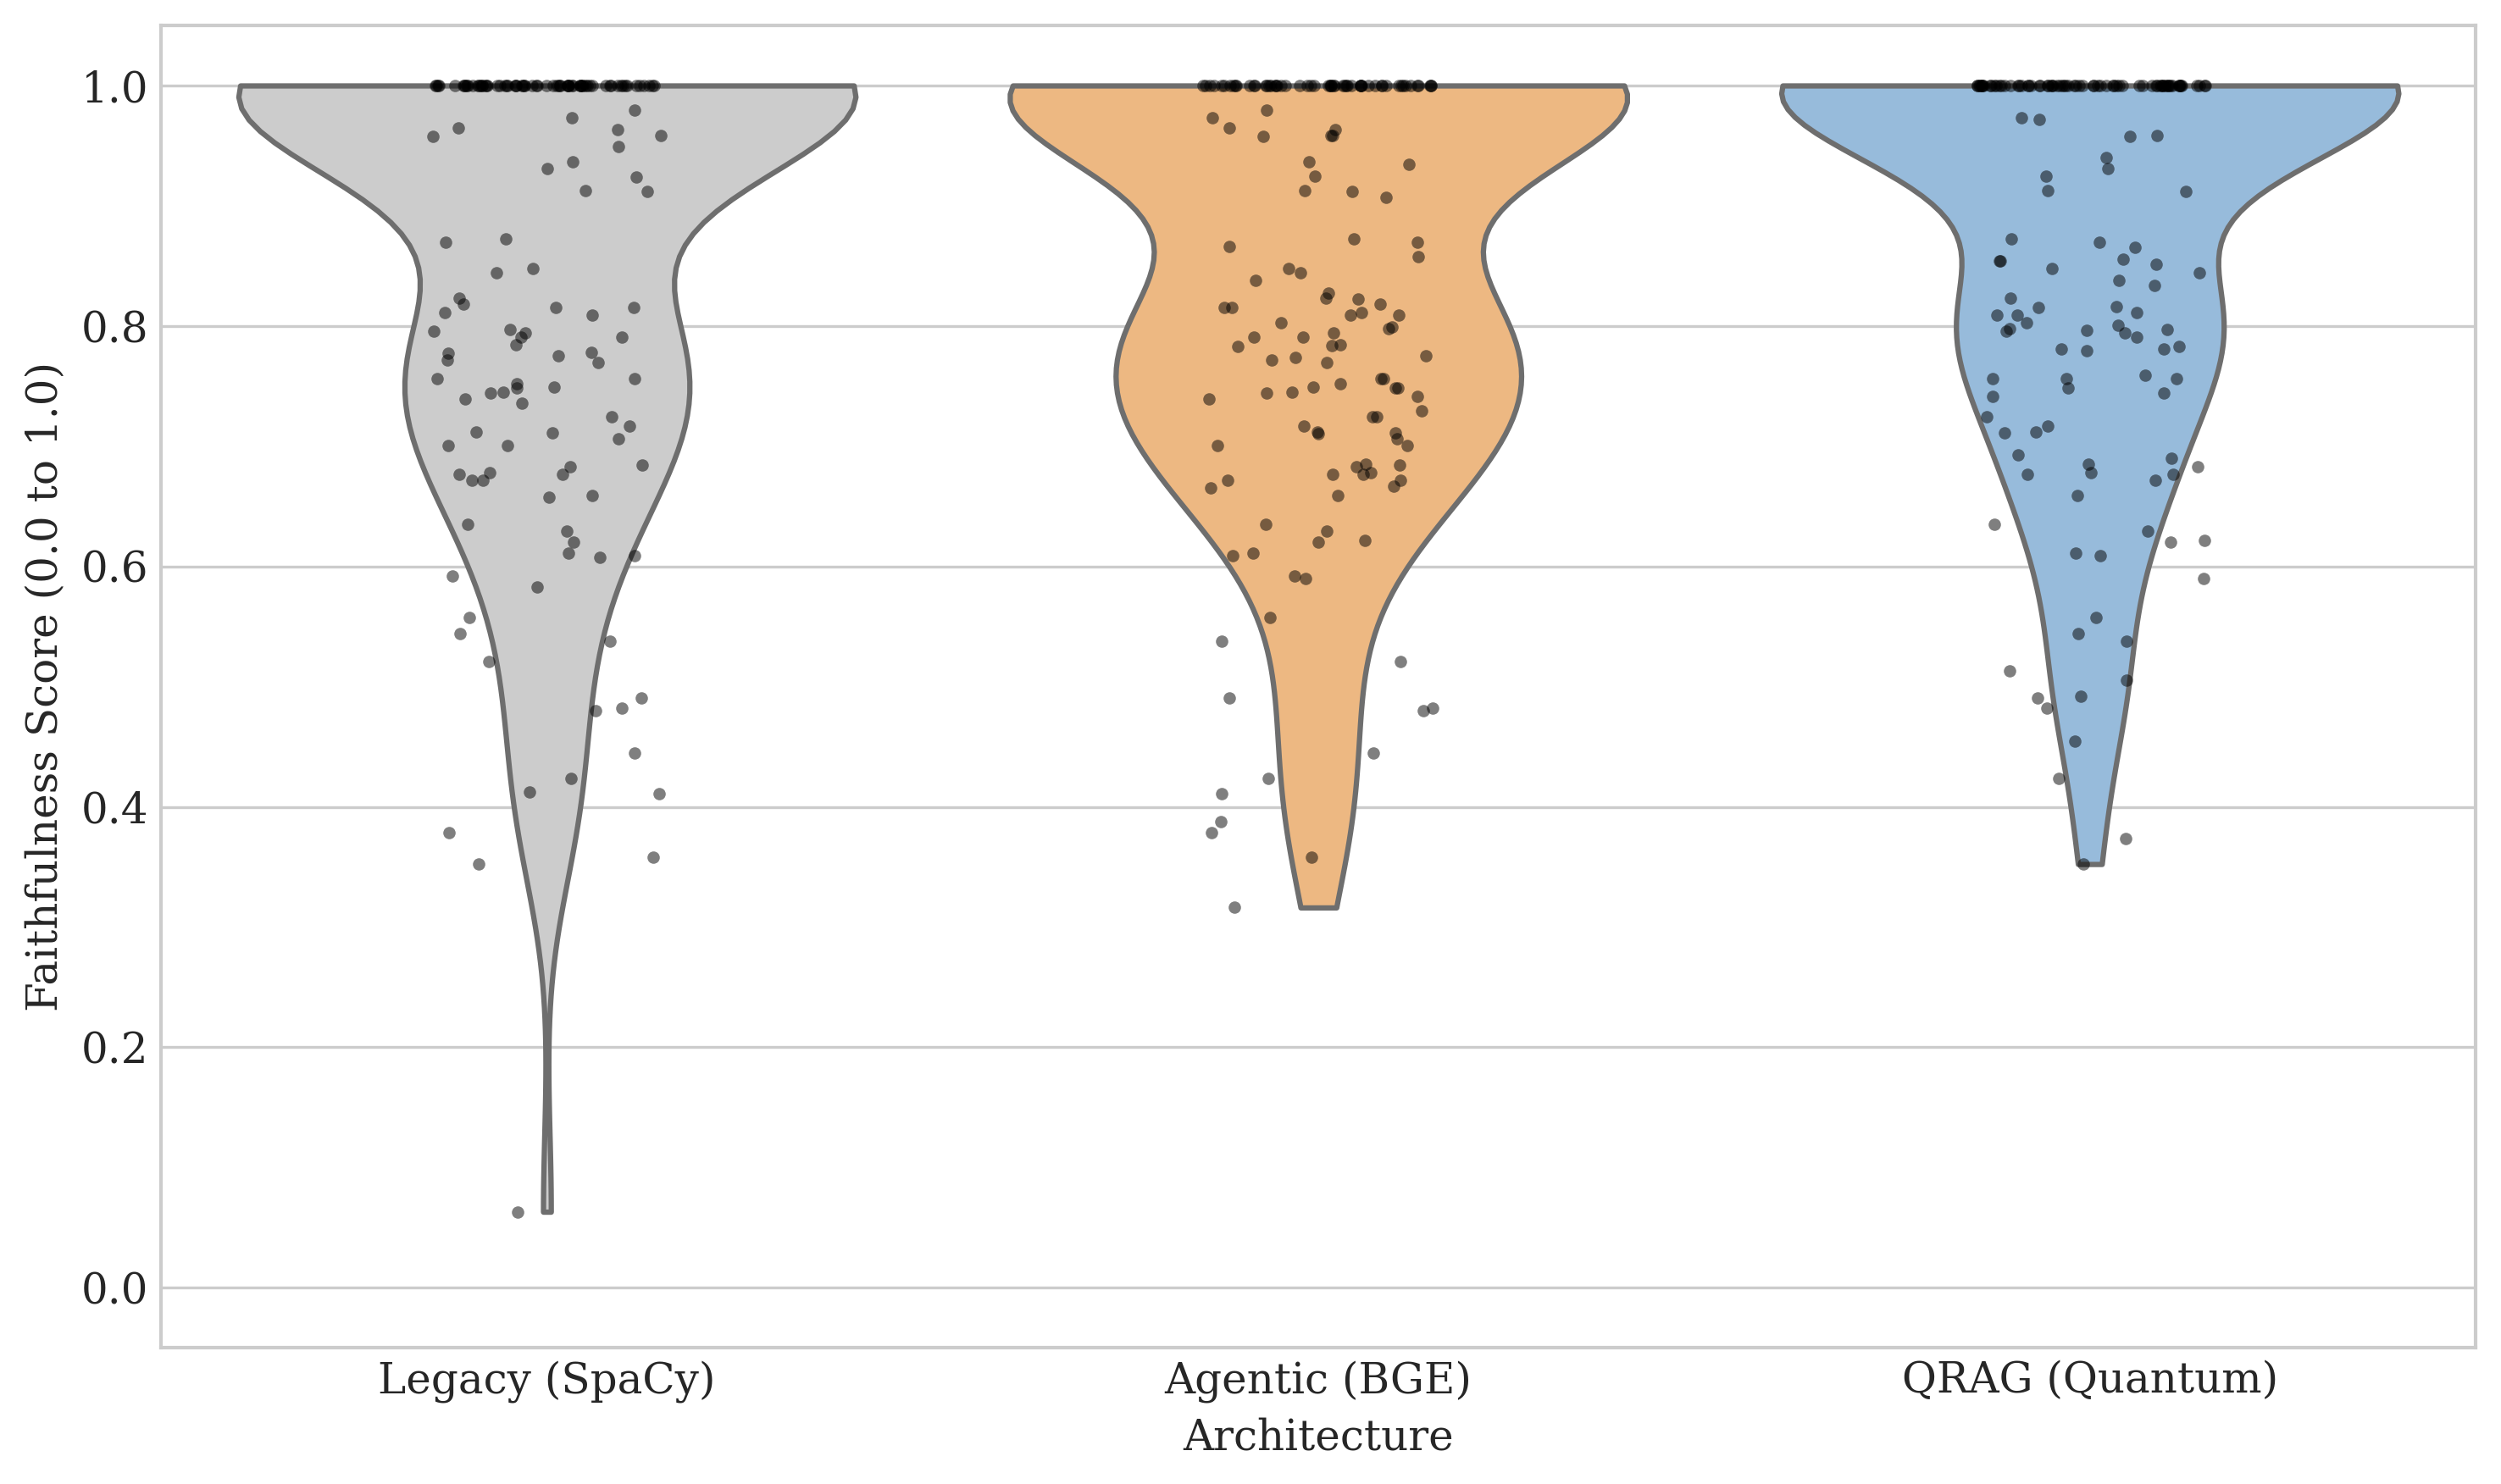

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("[SYSTEM] Rendering Graph A4: Violin Density Distribution (Patched)...")

target_csv = "qrag_telemetry_N150_run_1776587682.csv"
if not os.path.exists(target_csv):
    print(f"[ERROR] Could not find {target_csv}")
    exit()

df = pd.read_csv(target_csv)
n_queries = len(df)

def safe_norm(col_name):
    raw = pd.to_numeric(df[col_name], errors='coerce').fillna(0.0).values
    return raw / 100.0 if raw.max() > 1.0 else raw

s_faith = safe_norm('SpaCy_Faith')
a_faith = safe_norm('Agentic_Faith')
q_faith = safe_norm('Quantum_Faith')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.family': 'serif', 'font.size': 12, 'figure.dpi': 300})

fig, ax = plt.subplots(figsize=(10, 6))

plot_data = pd.DataFrame({
    'Ragas Answer Faithfulness': np.concatenate([s_faith, a_faith, q_faith]),
    'Architecture': (['Legacy (SpaCy)'] * n_queries + 
                    ['Agentic (BGE)'] * n_queries + 
                    ['QRAG (Quantum Research)'] * n_queries)
})

# 1. Plot the Violin (Density)
# Added 'hue' and 'legend=False' to silence the Seaborn v0.14+ deprecation warning.
sns.violinplot(
    x='Architecture', 
    y='Ragas Answer Faithfulness', 
    hue='Architecture',
    data=plot_data, 
    palette=['#cccccc', '#ffb870', '#8cbce6'], 
    inner=None, 
    linewidth=1.5,
    cut=0, 
    legend=False,
    ax=ax
)

# 2. Overlay the Strip Plot (Guarantees 100% Data Retention)
# Using stripplot with jitter handles the massive 1.0 ceiling clustering perfectly.
sns.stripplot(
    x='Architecture', 
    y='Ragas Answer Faithfulness', 
    data=plot_data, 
    color='black', 
    alpha=0.5, 
    size=3.5,
    jitter=0.15, 
    ax=ax
)

ax.set_ylabel('Faithfulness Score (0.0 to 1.0)')
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
output_file = "Graph_A4_Final_Faithfulness_Violin_FIXED.png"
plt.savefig(output_file, bbox_inches='tight')
print(f"[SUCCESS] High-resolution density graph saved to: {output_file}")